# SVD and Image Compression
SVD is, in simple terms, a data reduction tool that distills data into essential components that we can use/analyze
##### Uses : 
- Image compression
- Noise reduction
- Facial Recognition
- Recommendation patterns
- Google Page Rank

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
from skimage import data, color
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'serif',
})
print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. The SVD Theorem

Let $A$ be an $m \times n$ matrix with rank $r$. Then there exist:
- $U$: $m \times m$ orthogonal matrix (columns = **left singular vectors** $\mathbf{u}_i$)
- $\Sigma$: $m \times n$ "diagonal" matrix with $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r > 0$
- $V$: $n \times n$ orthogonal matrix (columns = **right singular vectors** $\mathbf{v}_i$)

such that:
$$\boxed{A = U \Sigma V^T}$$

The structure of $\Sigma$:
$$\Sigma = \begin{bmatrix} D & 0 \\ 0 & 0 \end{bmatrix}, \quad D = \operatorname{diag}(\sigma_1, \ldots, \sigma_r)$$

**Key relationships:**
- Columns of $V$ are eigenvectors of $A^TA$
- Columns of $U$ are eigenvectors of $AA^T$
- $A\mathbf{v}_i = \sigma_i \mathbf{u}_i$ for $1 \leq i \leq r$
- $\{\mathbf{u}_1, \ldots, \mathbf{u}_r\}$ is an orthonormal basis for $\operatorname{Col}(A)$
- $\{\mathbf{v}_{r+1}, \ldots, \mathbf{v}_n\}$ is an orthonormal basis for $\operatorname{Nul}(A)$

---
## 2. Computing an SVD 



$$A = \begin{bmatrix} 4 & 11 & 14 \\ 8 & 7 & 2 \end{bmatrix}$$

**Step 1:** Compute $A^TA$ and find its eigenvalues/eigenvectors → $V$ and $\Sigma$.

**Step 2:** For each nonzero $\sigma_i$, set $\mathbf{u}_i = \frac{1}{\sigma_i} A\mathbf{v}_i$ → build $U$.

**Step 3:** Verify $A = U\Sigma V^T$.

In [8]:

A = np.array([[4., 11., 14.],
              [8.,  7.,  2.]])

print("=" * 50)
print("STEP 1: Compute A^T A and its eigendecomposition")
print("=" * 50)
ATA = A.T @ A
print("A^T A =\n", ATA)

eigvals, eigvecs = np.linalg.eigh(ATA)  # eigh for symmetric matrices
# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print(f"\nEigenvalues of A^T A: {np.round(eigvals, 4)}")
print("From Lay: 360, 90, 0  ✓" if np.allclose(eigvals, [360, 90, 0], atol=1e-6) else "")

V = eigvecs
print("\nV (right singular vectors, columns):")
print(np.round(V, 4))

print("\n" + "=" * 50)
print("STEP 2: Singular values → Σ")
print("=" * 50)
sigma = np.sqrt(np.maximum(eigvals, 0))
print(f"Singular values σ: {np.round(sigma, 4)}")
r = np.sum(sigma > 1e-10)   # rank
print(f"Rank r = {r}")

Sigma = np.zeros_like(A)
Sigma[0,0] = sigma[0]; Sigma[1,1] = sigma[1]
print("\nΣ =\n", np.round(Sigma, 4))

print("\n" + "=" * 50)
print("STEP 3: Build U from u_i = (1/σ_i) A v_i")
print("=" * 50)
U = np.zeros((A.shape[0], A.shape[0]))
for i in range(r):
    U[:, i] = (A @ V[:, i]) / sigma[i]
print("U =\n", np.round(U, 4))

print("\n" + "=" * 50)
print("STEP 4: Verify A = U Σ V^T")
print("=" * 50)
A_reconstructed = U @ Sigma @ V.T
print("U Σ V^T =\n", np.round(A_reconstructed, 4))
print("\nOriginal A =\n", A)
print("\nMatch?", np.allclose(A, A_reconstructed, atol=1e-6))

STEP 1: Compute A^T A and its eigendecomposition
A^T A =
 [[ 80. 100.  72.]
 [100. 170. 168.]
 [ 72. 168. 200.]]

Eigenvalues of A^T A: [399.4506  50.5494  -0.    ]


V (right singular vectors, columns):
[[-0.3548 -0.7669  0.5348]
 [-0.6481 -0.2106 -0.7319]
 [-0.6739  0.6062  0.4222]]

STEP 2: Singular values → Σ
Singular values σ: [19.9863  7.1098  0.    ]
Rank r = 2

Σ =
 [[19.9863  0.      0.    ]
 [ 0.      7.1098  0.    ]]

STEP 3: Build U from u_i = (1/σ_i) A v_i
U =
 [[-0.8997  0.4364]
 [-0.4364 -0.8997]]

STEP 4: Verify A = U Σ V^T
U Σ V^T =
 [[ 4. 11. 14.]
 [ 8.  7.  2.]]

Original A =
 [[ 4. 11. 14.]
 [ 8.  7.  2.]]

Match? True


In [23]:
print("NumPy SVD (numpy.linalg.svd):")
U_np, s_np, Vt_np = np.linalg.svd(A)

print(f"U =\n{np.round(U_np, 4)}")
print(f"\nSingular values s = {np.round(s_np, 4)}")
print(f"\nV^T =\n{np.round(Vt_np, 4)}")

# Reconstruct
Sigma_np = np.zeros_like(A)
for i, sv in enumerate(s_np):
    Sigma_np[i, i] = sv
print("\nReconstruction matches original:",
      np.allclose(A, U_np @ Sigma_np @ Vt_np))



NumPy SVD (numpy.linalg.svd):
U =
[[-0.8997 -0.4364]
 [-0.4364  0.8997]]

Singular values s = [19.9863  7.1098]

V^T =
[[-0.3548 -0.6481 -0.6739]
 [ 0.7669  0.2106 -0.6062]
 [ 0.5348 -0.7319  0.4222]]

Reconstruction matches original: True


---
## 3. The Rank-$k$ Approximation


The SVD gives an **outer product expansion**:
$$A = \sigma_1 \mathbf{u}_1 \mathbf{v}_1^T + \sigma_2 \mathbf{u}_2 \mathbf{v}_2^T + \cdots + \sigma_r \mathbf{u}_r \mathbf{v}_r^T$$

Each term $\sigma_i \mathbf{u}_i \mathbf{v}_i^T$ is a **rank-1 matrix** — think of it as one "layer" of the image.

The **rank-$k$ approximation** keeps only the first $k$ terms:
$$A_k = \sum_{i=1}^{k} \sigma_i \mathbf{u}_i \mathbf{v}_i^T$$


---
## 4. Image Compression: Theory

### How a Grayscale Image Becomes a Matrix

A grayscale image of size $m \times n$ pixels is exactly an $m \times n$ matrix $A$, where each entry $a_{ij} \in [0, 255]$ is the brightness of pixel $(i, j)$.

### SVD Compression Pipeline

$$A \;\xrightarrow{\text{SVD}}\; U \Sigma V^T \;\xrightarrow{\text{keep top }k}\; A_k = \sum_{i=1}^k \sigma_i \mathbf{u}_i \mathbf{v}_i^T$$



---
## 5. Image Compression Demo



In [ ]:
img = Image.open("greg.jpeg").convert("L") 
img_gray = np.array(img, dtype=float)
m, n = img_gray.shape

U, s, Vt = np.linalg.svd(img_gray, full_matrices=False)# econ svd

print(f"Image: {m} × {n}")
print(f"U shape: {U.shape}")
print(f"s shape: {s.shape}")
print(f"Vt shape: {Vt.shape}")
print(f"Total singular values: {len(s)}")
print(f"Top 10 singular values: {np.round(s[:10], 1)}")

Image: 2316 × 3088
U shape: (2316, 2316)
s shape: (2316,)
Vt shape: (2316, 3088)
Total singular values: 2316
Top 10 singular values: [434440.2  82553.3  37769.4  23459.1  21183.1  18273.8  15207.3  13906.1
  12868.6  10263.4]


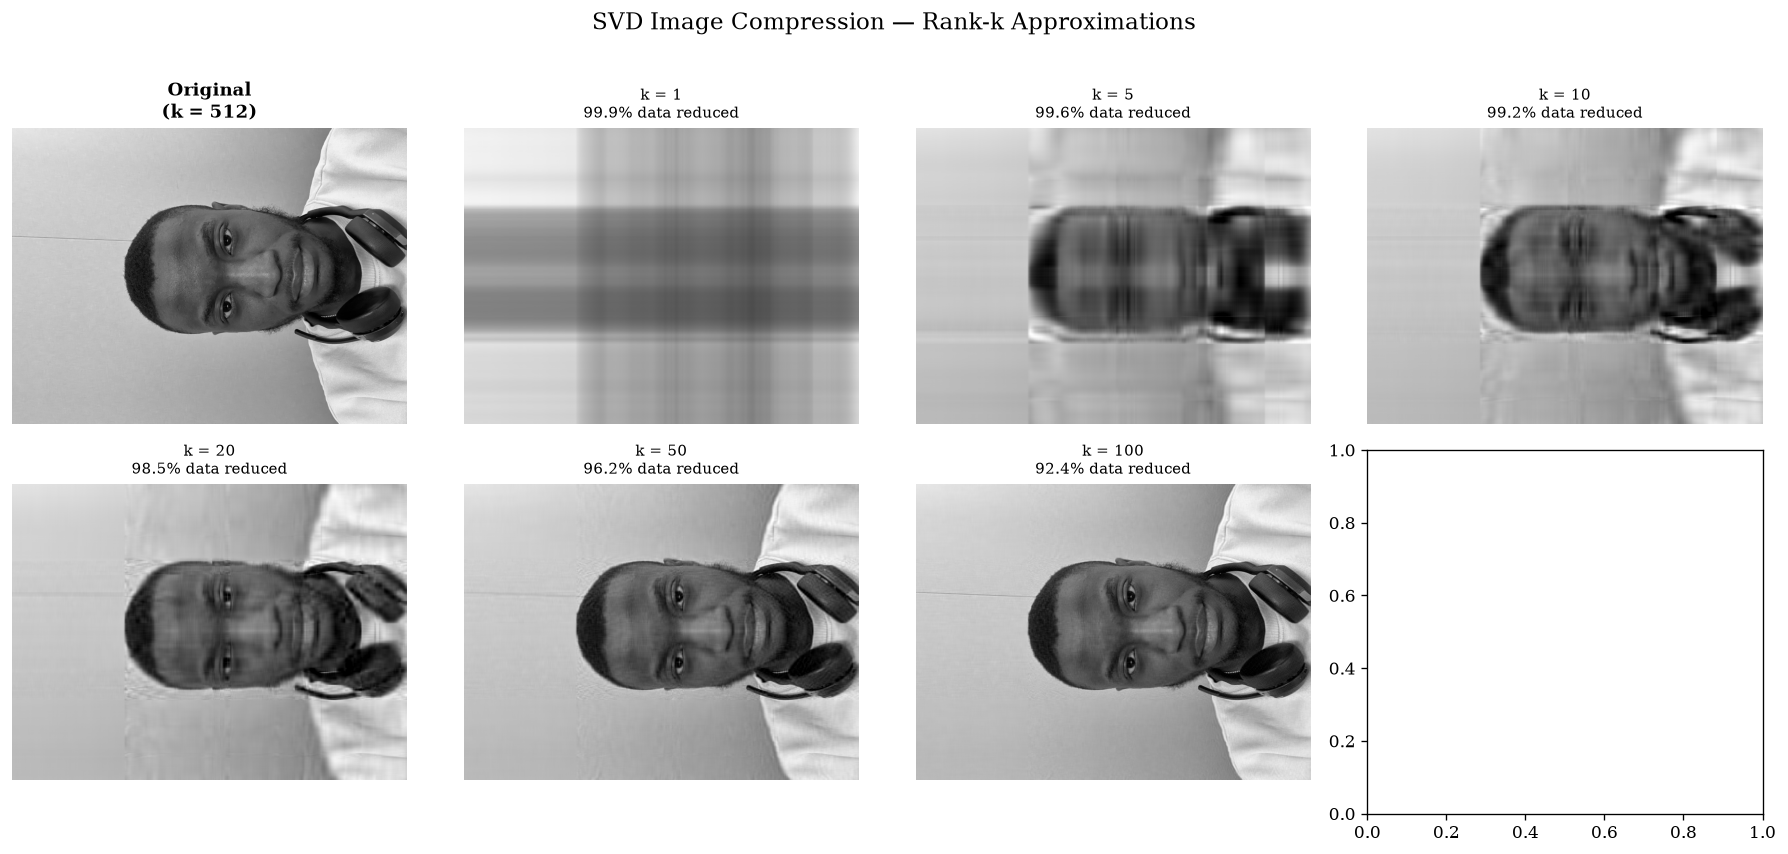

In [27]:
def rank_k_approx(U, s, Vt, k):
    """Compute the rank-k SVD approximation."""
    return (U[:, :k] * s[:k]) @ Vt[:k, :]

def compression_ratio(m, n, k):
    return (m * n) / (k * (m + n + 1))

k_values = [1, 5, 10, 20, 50, 100]

fig, axes = plt.subplots(2, len(k_values)//2 + 1, figsize=(15, 7))
axes = axes.flatten()

# Original
axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original\n(k = 512)', fontsize=11, fontweight='bold')
axes[0].axis('off')

for idx, k in enumerate(k_values):
    A_k = rank_k_approx(U, s, Vt, k)
    A_k_clipped = np.clip(A_k, 0, 255)
    ratio = compression_ratio(m, n, k)
    data_lost = (1 - 1/ratio) * 100

    ax = axes[idx + 1]
    ax.imshow(A_k_clipped, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'k = {k}\n{data_lost:.1f}% data reduced',
                 fontsize=9)
    ax.axis('off')

plt.suptitle('SVD Image Compression — Rank-k Approximations', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Plot of the singular values

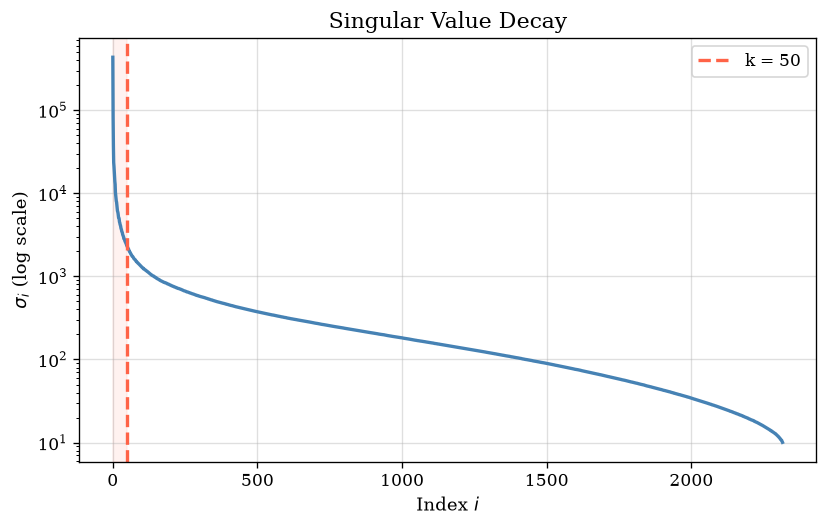

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.semilogy(s, color='steelblue', lw=2)
ax.set_xlabel('Index $i$')
ax.set_ylabel('$\\sigma_i$ (log scale)')
ax.set_title('Singular Value Decay')
ax.grid(True, alpha=0.4)

k = 50  
ax.axvline(k, color='tomato', ls='--', lw=2, label=f'k = {k}')
ax.axvspan(0, k, color='tomato', alpha=0.08)
ax.legend()

plt.tight_layout()
plt.show()

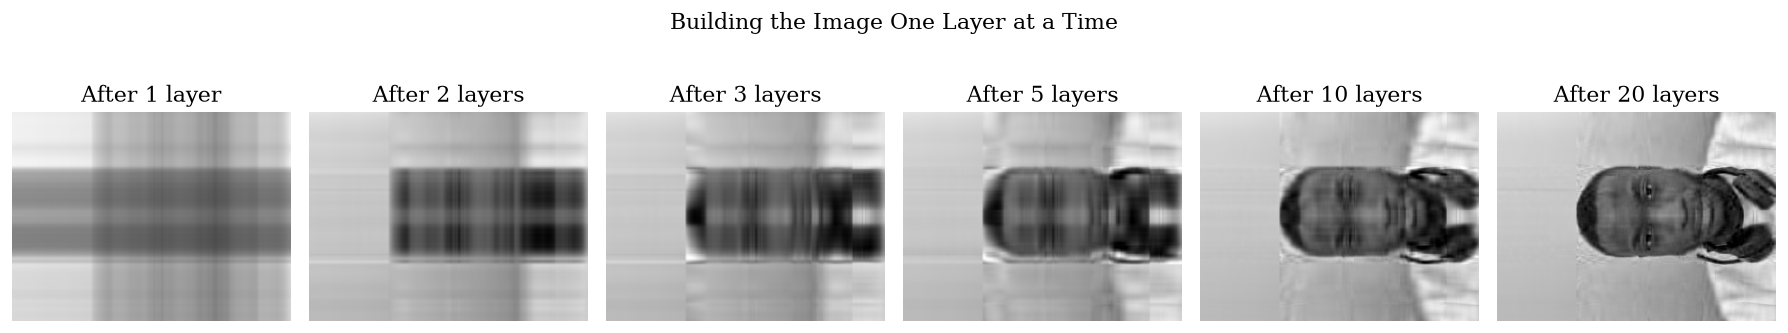

In [ ]:
# image build up layer by layer
fig, axes = plt.subplots(1, 6, figsize=(15, 3.2))
cumulative = np.zeros_like(img_gray)
show_at = [1, 2, 3, 5, 10, 20]

ax_idx = 0
for i in range(max(show_at)):
    cumulative += s[i] * np.outer(U[:, i], Vt[i, :])
    if (i + 1) in show_at:
        ax = axes[ax_idx]
        ax.imshow(np.clip(cumulative, 0, 255), cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'After {i+1} layer{"s" if i>0 else ""}')
        ax.axis('off')
        ax_idx += 1

plt.suptitle('Building the Image One Layer at a Time', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Color Image Compression

For a color image (RGB), apply SVD independently to each of the three channels (R, G, B) and recombine.

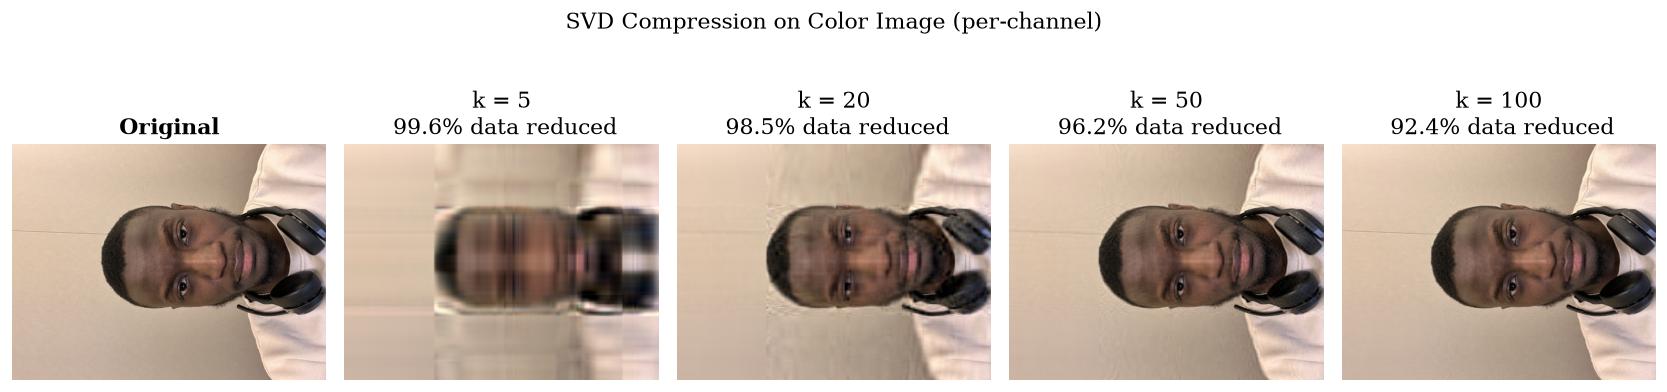

Note: Each of the 3 channels is compressed separately.
Total storage for rank-k color: 3 × k × (m+n+1) values.


In [ ]:
def compress_color_image(img_rgb, k):
    """SVD-compress each RGB channel independently."""
    compressed = np.zeros_like(img_rgb, dtype=float)
    for c in range(3):
        channel = img_rgb[:, :, c].astype(float)
        U_c, s_c, Vt_c = np.linalg.svd(channel, full_matrices=False)
        compressed[:, :, c] = rank_k_approx(U_c, s_c, Vt_c, k)
    return np.clip(compressed, 0, 255).astype(np.uint8)

img_color = Image.open("greg.jpeg")   
img_color = np.array(img_color, dtype=float)
m_c, n_c = img_color.shape[:2]

k_vals_color = [5, 20, 50, 100]
fig, axes = plt.subplots(1, len(k_vals_color) + 1, figsize=(14, 4))

axes[0].imshow(img_color.astype(np.uint8))
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for idx, k in enumerate(k_vals_color):
    comp = compress_color_image(img_color, k)
    ratio = (m_c * n_c) / (k * (m_c + n_c + 1))
    data_lost = (1 - 1/ratio) * 100  # % reduction in stored data
    axes[idx+1].imshow(comp)
    axes[idx+1].set_title(f'k = {k}\n {data_lost:.1f}% data reduced')
    axes[idx+1].axis('off')

plt.suptitle('SVD Compression on Color Image (per-channel)', fontsize=13)
plt.tight_layout()
plt.show()

print("Note: Each of the 3 channels is compressed separately.")
print(f"Total storage for rank-k color: 3 × k × (m+n+1) values.")